# Noise Diode Temperature

The temperature of the noise diode is a key value in the calibration of single dish observations.
This can be appreciated from the standard calibration equation for a single dish (see e.g., [Winkel et al. 2012](ui.adsabs.harvard.edu/abs/2012A%26A...540A.140W/abstract)):

$$
T_{\mathrm{A}}=T_{\mathrm{cal}}\left[\frac{P_{\mathrm{off}}^{\mathrm{cal}}}{P_{\mathrm{off}}}-1\right]^{-1}\frac{P_{\mathrm{on}}-P_{\mathrm{off}}}{P_{\mathrm{off}}}
$$
where $T_{\mathrm{A}}$ is the antenna temperature, $T_{\mathrm{cal}}$ is the temperature of the noise diode, $P_{\mathrm{off}}$ is the power recorded toward the reference position (e.g., off-source), $P_{\mathrm{off}}^{\mathrm{cal}}$ is the power recorded toward the reference position with the noise diode on, and $P_{\mathrm{on}}$ is the power recorded toward the target position (e.g., on-source).
Thus, the derived antenna temperature is directly proportional to the temperature of the noise diode.
$T_{\mathrm{cal}}$ can be polarization, feed, frequency and time dependent (see e.g., [Goddy et al 2020](https://ui.adsabs.harvard.edu/abs/2020RNAAS...4....3G/abstract)).

In order to ensure that precise and up-to-date values of $T_{\mathrm{cal}}$ are used, during an observation one should observe a standard flux calibrator with the same spectral setup as that used for the science observations.

In this notebook we present the math used by dysh to derive the temperature of the noise diode, and an example of how dysh can be used to derive $T_{\mathrm{cal}}$.

## Linear Case

If the response of the telescope to the incoming radiation is linear, then the recorded power can be described as:
$$
P=G(T_{\mathrm{A}}+T_{\mathrm{sys}}),
$$
with $G$ the gain of the telescope and $T_{\mathrm{sys}}$ the system temperature.

Assuming position switched observations, then the above can be used to derive the temperature of the noise diode as:
$$
T_{\mathrm{cal}}=T_{\mathrm{A}}^{\mathrm{src}}\left(\frac{P_{\mathrm{off}}^{\mathrm{cal}} - P_{\mathrm{off}}}{P_{\mathrm{on}} - P_{\mathrm{off}}}\right),
$$
with $T_{\mathrm{A}}^{\mathrm{src}}$ the equivalent temperature of the flux calibrator:
$$
T_{\mathrm{A}}^{\mathrm{src}}=\frac{A_{\mathrm{p}}}{2k_{\mathrm{B}}}\eta\exp[-\tau_{\nu} A]S_{\nu},
$$
where $\eta$ is the telescope efficiency, $A_{\mathrm{p}}$ the telescope area, $k_{\mathrm{B}}$ the Boltzmann constant, $\tau_{\nu}$ the zenith opacity, $A$ the airmass and $S_{\nu}$ the flux density of the calibrator.

## Quadratic Case

If the response of the telescope to the incoming radiation is not linear, then the specific will depend on how far from linear the response is. 
For the GBT a resonable model is obtained by adding a quadratic gain term, $H$.
In this case we have:
$$
T_{\mathrm{cal}}=gP_{\mathrm{off}}^{\mathrm{cal}} + h\left(P_{\mathrm{off}}^{\mathrm{cal}}\right)^{2} - T_{\mathrm{sys}}.
$$
The system temperature is
$$
T_{\mathrm{sys}}=gP_{\mathrm{off}}+h\left(P_{\mathrm{off}}\right)^{2}
$$
and the inverse gain factors g and h are:
$$
g=\frac{h}{q},
$$
$$
h=T_{\mathrm{A}}^{\mathrm{src}}\left(\frac{1}{P_{\mathrm{on}}^{\mathrm{cal}}-P_{\mathrm{off}}^{\mathrm{cal}}}-\frac{1}{P_{\mathrm{on}}-P_{\mathrm{off}}}\right)\left(\frac{1}{P_{\mathrm{on}}^{\mathrm{cal}}+P_{\mathrm{off}}^{\mathrm{cal}}-P_{\mathrm{on}}-P_{\mathrm{off}}}\right),
$$
and
$$
q=\frac{P_{\mathrm{on}}-P_{\mathrm{on}}^{\mathrm{cal}}+P_{\mathrm{off}}^{\mathrm{cal}}-P_{\mathrm{off}}}{\left(P_{\mathrm{on}}^{\mathrm{cal}}\right)^{2}-\left(P_{\mathrm{off}}^{\mathrm{cal}}\right)^{2}-\left(P_{\mathrm{on}}\right)^{2}+\left(P_{\mathrm{off}}\right)^{2}}.
$$

## dysh Example

Now we turn to how to use dysh to derive $T_{\mathrm{cal}}$.
We will use data from the HI-survey example.
From that data set we will only use scans 226 and 227, as they contain good position switched observations of a flux calibrator (3C286).

### Compute Noise Diode Temperature

The dysh function used to compute $T_{\mathrm{cal}}$ is [GBTFITSLoad.gettcal](https://dysh.readthedocs.io/en/latest/reference/modules/dysh.fits.html#dysh.fits.gbtfitsload.GBTFITSLoad.gettcal).

In [1]:
from dysh.util.files import dysh_data
from dysh.fits.gbtfitsload import GBTFITSLoad

In [2]:
filename = dysh_data(example="survey")

In [3]:
sdfits = GBTFITSLoad(filename)

Now we call ``gettcal``, with scan 227 as signal and scan 226 as reference (these were OffOn observations), and specify polarization 0.
To compute the noise diode temperature we require a value of the zenith opacity.
For observations around 21 cm, a value of 0.008 is representative of most typical considition at the GBT.

In [4]:
tcal_0 = sdfits.gettcal(scan=227, ref=226, plnum=0, fdnum=0, ifnum=0, zenith_opacity=0.008)

The return from ``gettcal`` is a [TCal](https://dysh.readthedocs.io/en/latest/reference/modules/dysh.spectra.html#dysh.spectra.tcal.TCal) object, which is almosyt the same as a ``Spectrum`` with some additional attributes: name and snu.

In [5]:
tcal_0.name

'3C286'

In [6]:
tcal_0.snu

<Quantity [14.95036961, 14.95040185, 14.95043409, ..., 15.22017527,
           15.22020894, 15.22024261] Jy>

The noise diode values can be plotted as a function of frequency as if this were a ``Spectrum``.
To better view the variations with frequency, we limit the y-axis.

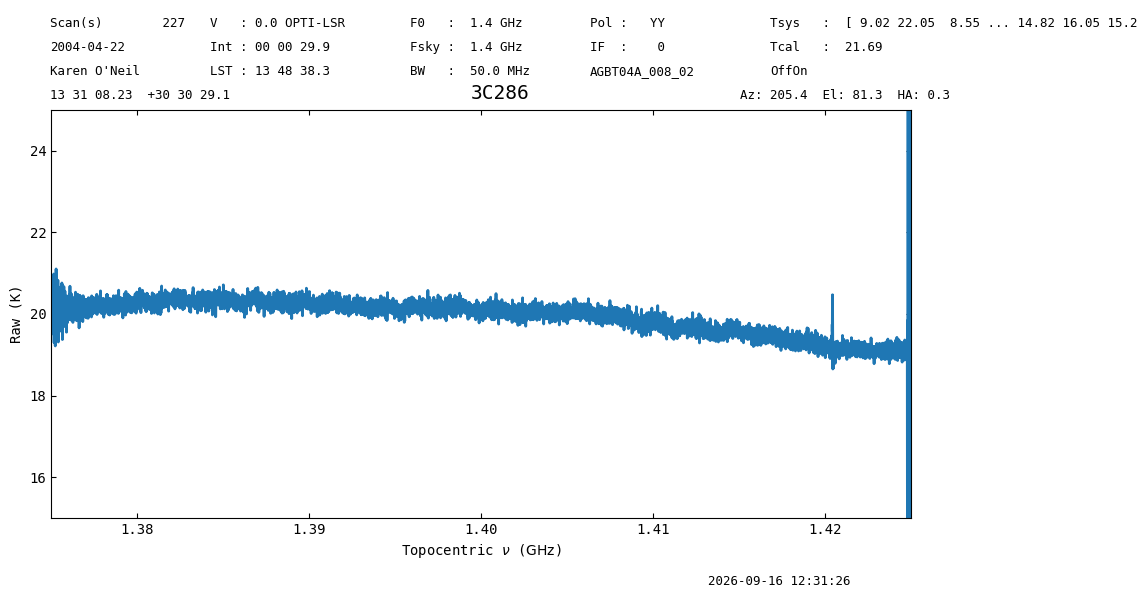

In [7]:
p0 = tcal_0.plot(ymin=15, ymax=25)

By default dysh uses the quadratic model.
We can recompute using the linear model by specifying the model keyword.

In [8]:
tcal_0l = sdfits.gettcal(scan=227, ref=226, plnum=0, fdnum=0, ifnum=0, zenith_opacity=0.008, method="linear")

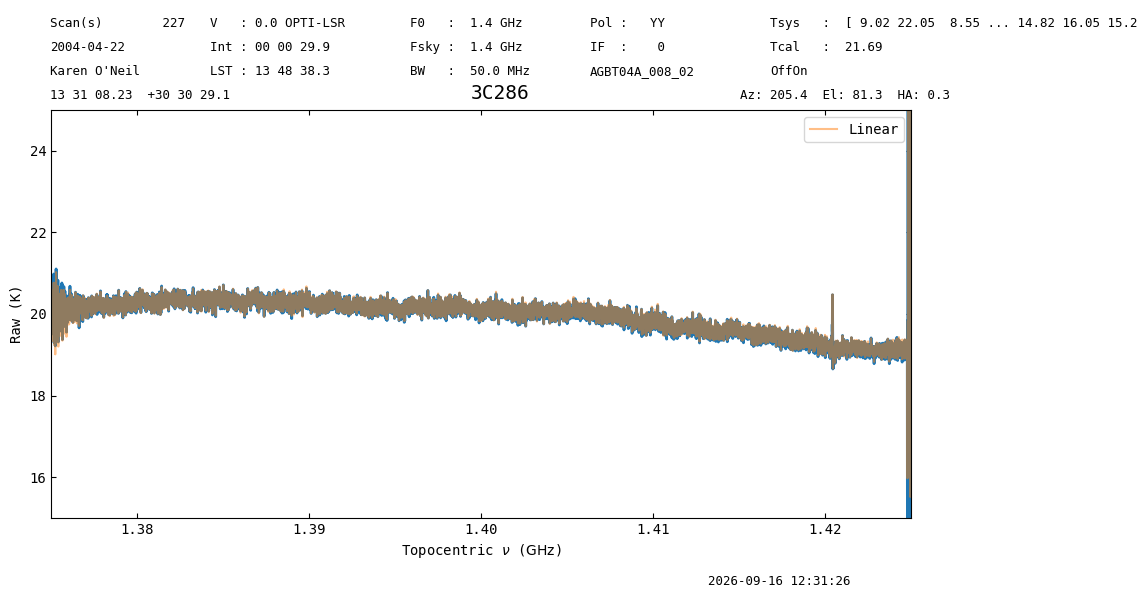

In [9]:
p0.oshow(tcal_0l, alpha=0.5, label="Linear")
p0.show()

Both methods (linear and quadratic) produce similar results.
This suggests that the telescope response was linear for these observations.
For brighter sources, the differences can be more significant.

To get the mean value of the noise diode temperature, averaged over the inner 80% of the spectral window, use the [TCal.get_tcal](https://dysh.readthedocs.io/en/latest/reference/modules/dysh.spectra.html#dysh.spectra.tcal.TCal.get_tcal) function.
The return of this function is a single value in K.

In [10]:
tcal_0.get_tcal()

np.float32(20.003805)

### Using the Noise Diode Temperature

Now that we have computed the noise diode temperature, we will want to use it during calibration.
There are two options for doing this: provide the value of the noise diode temperature in the calls to calibration routines, or update the TCAL column in the ``GBTFITSLoad`` object.

#### Providing a value for the noise diode during calibration

The argument used to specify a custom value for the noise diode temperature is ``t_cal``.
This takes a float in K.

Here's an example of how to use it:

In [11]:
ta = sdfits.getsigref(scan=227, ref=226, 
                      plnum=0, fdnum=0, ifnum=0, 
                      zenith_opacity=0.008, 
                      t_cal=20., 
                      units="Flux").timeaverage()

We calibrated using a noise diode temperature of 20 K (close to the actual value), and specified that the calibration be in flux units so we can compare the observed flux to the model.

Now we plot the observed flux and overlay the model values on the plot.

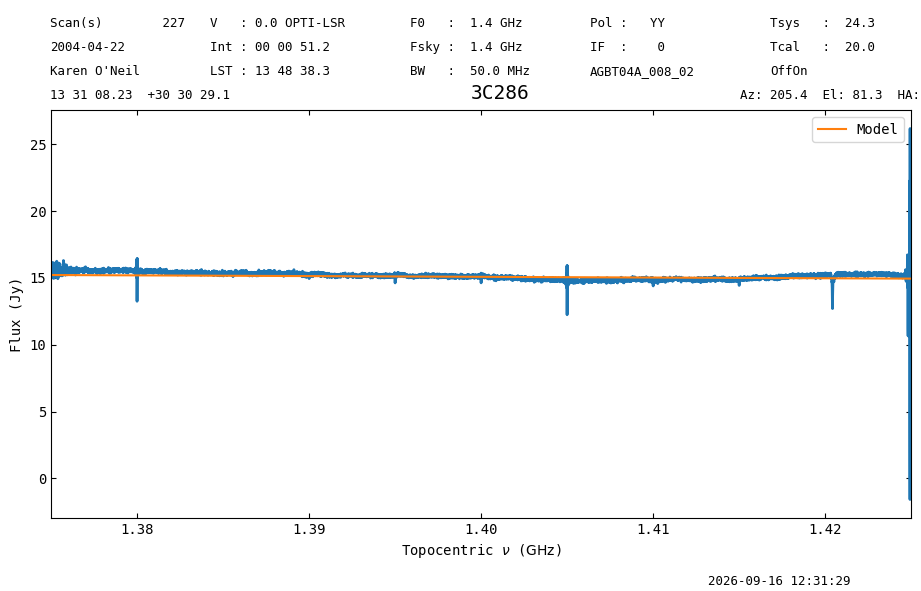

In [12]:
ta_plot = ta.plot(add_line={"y": tcal_0.snu, "label":"Model"})

#### Updating the TCAL column

In some cases it is preferable to update the TCAL column.
To do so, we can use the get and set methods of a ``GBTFITSLoad`` object.

First we get the current TCAL values:

In [13]:
tcal_column = sdfits["TCAL"]

Now we update them where it corresponds.
Since $T_{\mathrm{cal}}$ depends on the frequency, feed and polarization, this needs to be accounted for.

In [14]:
tcal_column[(sdfits["PLNUM"] == 0) & (sdfits["IFNUM"] == 0) & (sdfits["FDNUM"] == 0)] = tcal_0.get_tcal()

Finally, we replace the TCAL column with the updated values:

In [15]:
sdfits["TCAL"] = tcal_column.to_numpy()

/home/scratch/psalas/python/dysh-clean2/src/dysh/fits/sdfitsload.py:1510: UserWarning: Changing an existing SDFITS column TCAL
  warnings.warn(f"Changing an existing SDFITS column {items}")  # noqa: B028


Now we can repeat the calibration without specifying the ``t_cal`` argument and we should get equivalent results.

In [16]:
ta2 = sdfits.getsigref(scan=227, ref=226, 
                       plnum=0, fdnum=0, ifnum=0, 
                       zenith_opacity=0.008, 
                       units="Flux").timeaverage()

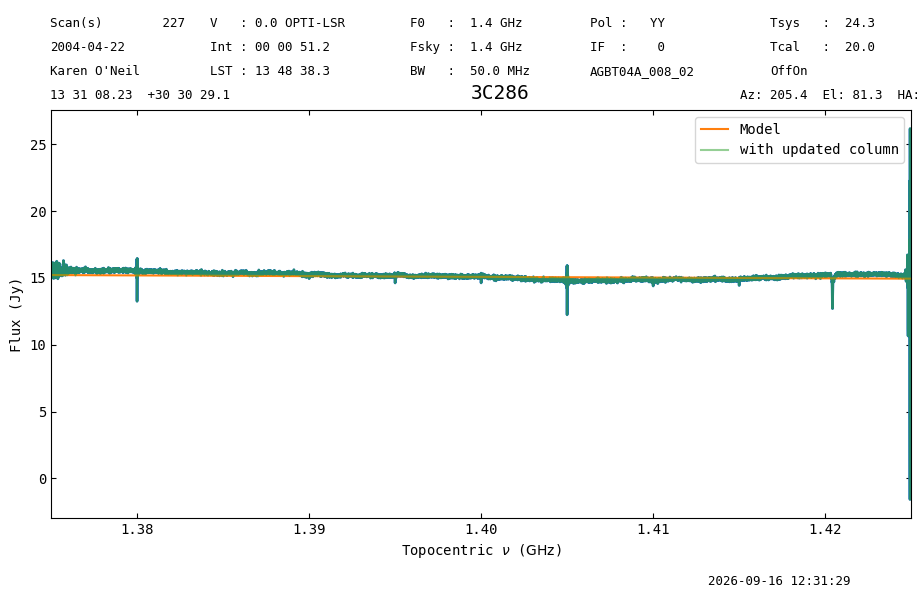

In [17]:
ta_plot.oshow(ta2, label="with updated column", alpha=0.5)
ta_plot.show()

The curves are on top of each other.

We can also confirm by subtracting them, and inspecting the flux values of the difference.
They should be close to zero Jy.

In [18]:
(ta - ta2).flux

<Quantity [-0.00327719, -0.0025754 , -0.00333089, ..., -0.00303461,
           -0.00285876, -0.0028993 ] Jy>